# 03 — Apply ML Models

**Project:** *Self-Tracking Longitudinal Analysis: Lifestyle Factors & Academic Productivity*

This notebook covers the **Apply ML methods** requirement:

1. **Regression (level prediction):** Predict the weekly productivity score from behavioral variables, evaluated with **Leave-One-Out Cross-Validation (LOO-CV)** due to the small sample size.
2. **Classification (direction of change):** Predict whether productivity **increases vs. stays/decreases** week-over-week, and visualize a **confusion matrix**.
3. **Feature Importance:** Identify which behavioral factors are most predictive using permutation importance.

## 0) Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

print('Libraries loaded.')

Libraries loaded.


## 1) Load Data

**Input:** Self-tracked weekly data collected throughout the semester.

| Variable | Type | Description |
|---|---|---|
| `week` | int | Week number (1–10) |
| `week_type` | str | regular / midterm (from academic calendar) |
| `study_hours` | float | Total hours studied that week |
| `sleep_avg` | float | Average hours of sleep per night |
| `stress_level` | int | Self-rated stress (1=low, 10=high) |
| `motivation_level` | int | Self-rated motivation (1=low, 10=high) |
| `language_difficulty` | int | Self-rated language difficulty (1=low, 10=high) |
| `productivity_score` | float | Composite academic outcome (quiz % + assignment completion %) |

In [2]:
# ---- Real weekly data collected throughout the semester ----
# Semester started end of February
# Data collected up to Week 10 (May 2nd)
#
# Exam dates: April 5, 6 (week 7), April 19 (week 8)
# Enrichment: week_type derived from official academic calendar
# Exam weeks: ~5 hrs/day x 5 days = ~25 hrs study
# Regular weeks: ~2-3 hrs/day x ~4 days = ~10 hrs study
# Grades: ~40-50% range -> productivity_score reflects exam performance
# Motivation: consistently low (3-4), declining toward week 9-10 (2-3)
# Stress: baseline 5-6, spikes to 8-9 on exam weeks
data = {
    'week':       [1,    2,    3,    4,    5,    6,    7,        8,        9,    10   ],
    'week_type':  ['regular','regular','regular','regular','regular','regular','midterm','midterm','regular','regular'],
    'study_hours':[10,   10,   9,    10,   9,    10,   25,       25,       10,   9    ],
    'sleep_avg':  [7.2,  7.0,  7.1,  7.0,  7.2,  7.0,  6.0,      6.2,      7.0,  7.1  ],
    'stress_level':[5,   5,    5,    5,    5,    6,    9,        8,        6,    6    ],
    'motivation_level':[4, 4,  4,    3,    3,    3,    3,        3,        2,    2    ],
    'language_difficulty':[5, 5, 5,  5,    5,    5,    6,        6,        5,    5    ],
    'productivity_score':[58, 56, 57, 55,  54,   53,   43,       46,       52,   50   ]
}

df = pd.DataFrame(data)

# Encode week_type as binary (1 = midterm, 0 = regular)
df['is_midterm'] = (df['week_type'] == 'midterm').astype(int)

feature_cols = ['study_hours', 'sleep_avg', 'stress_level',
                'motivation_level', 'language_difficulty', 'is_midterm']
X = df[feature_cols]
y = df['productivity_score']

print('Shape:', df.shape)
print('Features:', feature_cols)
print('Target: productivity_score')
df

Shape: (10, 9)
Features: ['study_hours', 'sleep_avg', 'stress_level', 'motivation_level', 'language_difficulty', 'is_midterm']
Target: productivity_score


,week,week_type,study_hours,sleep_avg,stress_level,motivation_level,language_difficulty,productivity_score,is_midterm
0,1,regular,10,7.2,5,4,5,58,0
1,2,regular,10,7.0,5,4,5,56,0
2,3,regular,9,7.1,5,4,5,57,0
3,4,regular,10,7.0,5,3,5,55,0
4,5,regular,9,7.2,5,3,5,54,0
5,6,regular,10,7.0,6,3,5,53,0
6,7,midterm,25,6.0,9,3,6,43,1
7,8,midterm,25,6.2,8,3,6,46,1
8,9,regular,10,7.0,6,2,5,52,0
9,10,regular,9,7.1,6,2,5,50,0


## 2) Note on Small Sample Size

With only **10 weekly observations**, a traditional train-test split is not meaningful.
Instead, **Leave-One-Out Cross-Validation (LOO-CV)** is used:
each iteration trains on 9 samples and tests on 1, cycling through all observations.

This is the standard approach for very small datasets and provides the most reliable
estimate of model performance given the data available.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
loo = LeaveOneOut()
print('LOO folds:', loo.get_n_splits(X_scaled))

LOO folds: 10


## 3) Task 1 — Regression: Predict Productivity Score

**Goal:** Predict the continuous productivity score from behavioral features.

Models tested:
- Linear Regression
- Ridge (L2 regularization)
- Lasso (L1 regularization)
- Random Forest Regressor
- Gradient Boosting Regressor

**Evaluation:** RMSE (lower = better) and R² (higher = better) via LOO-CV.

### 3.1 Model Training with LOO-CV

In [4]:
reg_models = {
    'Linear Regression':    LinearRegression(),
    'Ridge':                Ridge(alpha=1.0),
    'Lasso':                Lasso(alpha=0.1),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

reg_results = {}

for name, model in reg_models.items():
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in loo.split(X_scaled):
        X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_train, y_train)
        y_pred_all.append(model.predict(X_test)[0])
        y_true_all.append(y_test.values[0])
    r = rmse(y_true_all, y_pred_all)
    r2 = r2_score(y_true_all, y_pred_all)
    reg_results[name] = {'RMSE': round(r,3), 'R2': round(r2,3),
                          'y_true': y_true_all, 'y_pred': y_pred_all}
    print(f'{name:25s} | RMSE: {r:.3f} | R2: {r2:.3f}')

Linear Regression         | RMSE: 1.231 | R2: 0.928
Ridge                     | RMSE: 1.341 | R2: 0.915
Lasso                     | RMSE: 1.348 | R2: 0.914
Random Forest             | RMSE: 2.048 | R2: 0.801
Gradient Boosting         | RMSE: 2.032 | R2: 0.804


### 3.2 Results Table

In [5]:
reg_df = pd.DataFrame({
    'Model':  list(reg_results.keys()),
    'RMSE':   [v['RMSE'] for v in reg_results.values()],
    'R2':     [v['R2']   for v in reg_results.values()]
}).sort_values('RMSE').reset_index(drop=True)

print('=== Regression Performance (LOO-CV) ===')
print(reg_df.to_string(index=False))
print(f"\nBest model: {reg_df.iloc[0]['Model']} (RMSE={reg_df.iloc[0]['RMSE']})")

=== Regression Performance (LOO-CV) ===
            Model  RMSE    R2
Linear Regression 1.231 0.928
            Ridge 1.341 0.915
            Lasso 1.348 0.914
Gradient Boosting 2.032 0.804
    Random Forest 2.048 0.801

Best model: Linear Regression (RMSE=1.231)


### 3.3 Model Comparison — RMSE & R²

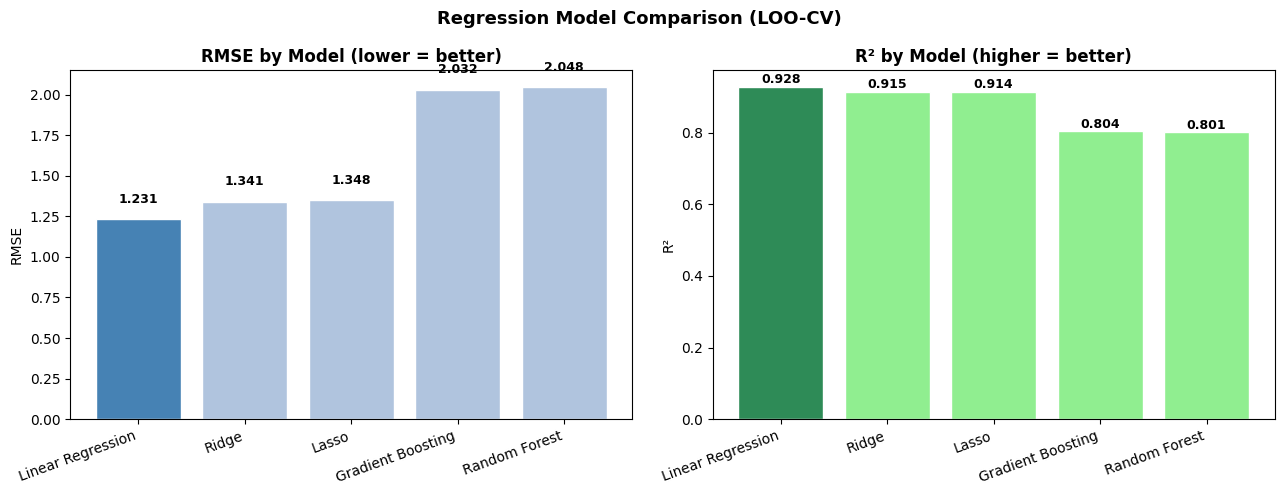

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# RMSE
colors_rmse = ['steelblue' if v == reg_df['RMSE'].min() else 'lightsteelblue' for v in reg_df['RMSE']]
bars = axes[0].bar(reg_df['Model'], reg_df['RMSE'], color=colors_rmse, edgecolor='white')
for bar, val in zip(bars, reg_df['RMSE']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 str(val), ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('RMSE by Model (lower = better)', fontweight='bold')
axes[0].set_xticklabels(reg_df['Model'], rotation=20, ha='right')
axes[0].set_ylabel('RMSE')

# R2
colors_r2 = ['seagreen' if v == reg_df['R2'].max() else 'lightgreen' for v in reg_df['R2']]
bars2 = axes[1].bar(reg_df['Model'], reg_df['R2'], color=colors_r2, edgecolor='white')
for bar, val in zip(bars2, reg_df['R2']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 str(val), ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('R² by Model (higher = better)', fontweight='bold')
axes[1].set_xticklabels(reg_df['Model'], rotation=20, ha='right')
axes[1].set_ylabel('R²')

plt.suptitle('Regression Model Comparison (LOO-CV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/regression_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Predicted vs Actual (Best Model)

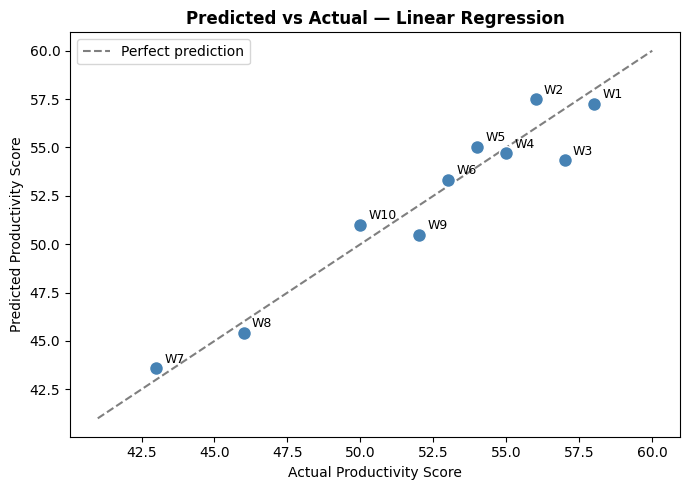

In [7]:
best_name = reg_df.iloc[0]['Model']
best = reg_results[best_name]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(best['y_true'], best['y_pred'], color='steelblue', s=100, edgecolors='white', zorder=3)
for i, (yt, yp) in enumerate(zip(best['y_true'], best['y_pred'])):
    ax.annotate(f'W{i+1}', (yt, yp), textcoords='offset points', xytext=(6, 4), fontsize=9)
mn = min(best['y_true']+best['y_pred'])-2
mx = max(best['y_true']+best['y_pred'])+2
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual Productivity Score')
ax.set_ylabel('Predicted Productivity Score')
ax.set_title(f'Predicted vs Actual — {best_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Feature Importance (Random Forest)

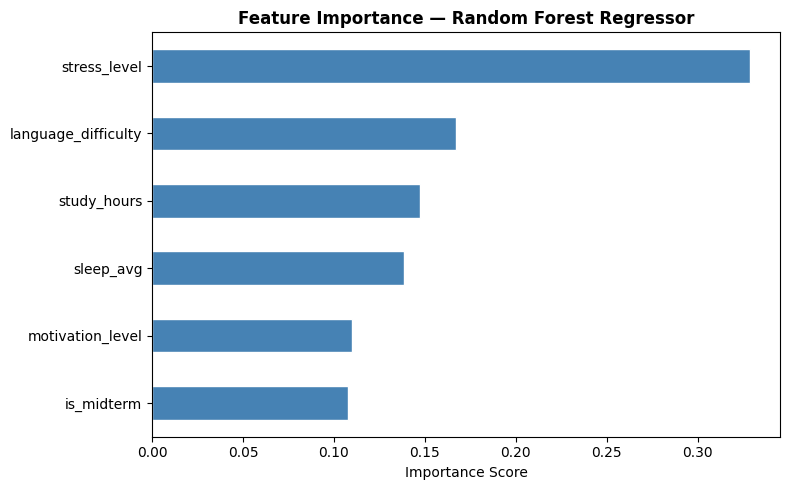

stress_level           0.328911
language_difficulty    0.167351
study_hours            0.147398
sleep_avg              0.138760
motivation_level       0.109788
is_midterm             0.107792


In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regressor', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(importances.sort_values(ascending=False).to_string())

## 4) Task 2 — Classification: Predict Productivity Direction

**Goal:** Predict whether productivity **increased** compared to the previous week.

- **1** = productivity increased week-over-week
- **0** = productivity stayed the same or decreased

This reframes the problem as a **directional forecast**, which is often more actionable
than predicting exact values.

In [9]:
# Create binary target: 1 if productivity increased from previous week
df['productivity_up'] = (df['productivity_score'].diff() > 0).astype(int)

# Drop first row (no previous week to compare)
df_clf = df.dropna().copy()
X_clf = df_clf[feature_cols]
y_clf = df_clf['productivity_up']

X_clf_scaled = StandardScaler().fit_transform(X_clf)

print('Classification target distribution:')
print(y_clf.value_counts().rename({0: 'Decreased/Same (0)', 1: 'Increased (1)'}))
df_clf[feature_cols + ['productivity_score', 'productivity_up']]

Classification target distribution:
productivity_up
Decreased/Same (0)    7
Increased (1)         3
Name: count, dtype: int64


,study_hours,sleep_avg,stress_level,motivation_level,language_difficulty,is_midterm,productivity_score,productivity_up
0,10,7.2,5,4,5,0,58,0
1,10,7.0,5,4,5,0,56,0
2,9,7.1,5,4,5,0,57,1
3,10,7.0,5,3,5,0,55,0
4,9,7.2,5,3,5,0,54,0
5,10,7.0,6,3,5,0,53,0
6,25,6.0,9,3,6,1,43,0
7,25,6.2,8,3,6,1,46,1
8,10,7.0,6,2,5,0,52,1
9,9,7.1,6,2,5,0,50,0


### 4.1 Model Training with LOO-CV

In [ ]:
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
}

clf_results = {}
loo_clf = LeaveOneOut()

for name, model in clf_models.items():
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in loo_clf.split(X_clf_scaled):
        X_train, X_test = X_clf_scaled[train_idx], X_clf_scaled[test_idx]
        y_train, y_test = y_clf.iloc[train_idx], y_clf.iloc[test_idx]
        model.fit(X_train, y_train)
        y_pred_all.append(model.predict(X_test)[0])
        y_true_all.append(y_test.values[0])
    acc = accuracy_score(y_true_all, y_pred_all)
    clf_results[name] = {'Accuracy': round(acc,3), 'y_true': y_true_all, 'y_pred': y_pred_all}
    print(f'{name:25s} | Accuracy: {acc:.3f}')

### 4.2 Classification Results

In [ ]:
clf_df = pd.DataFrame({
    'Model':    list(clf_results.keys()),
    'Accuracy': [v['Accuracy'] for v in clf_results.values()]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('=== Classification Performance (LOO-CV) ===')
print(clf_df.to_string(index=False))

# Accuracy bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if v == clf_df['Accuracy'].max() else 'lightsteelblue' for v in clf_df['Accuracy']]
bars = ax.bar(clf_df['Model'], clf_df['Accuracy'], color=colors, edgecolor='white')
for bar, val in zip(bars, clf_df['Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.0%}', ha='center', fontweight='bold')
ax.set_title('Classification Accuracy by Model (LOO-CV)', fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline (50%)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/classification_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Confusion Matrix (Best Classifier)

In [ ]:
best_clf_name = clf_df.iloc[0]['Model']
best_clf = clf_results[best_clf_name]

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    best_clf['y_true'], best_clf['y_pred'],
    display_labels=['Decreased/Same', 'Increased'],
    ax=ax, values_format='d'
)
ax.set_title(f'Confusion Matrix — {best_clf_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best classifier: {best_clf_name}')
print(f'Accuracy: {clf_df.iloc[0]["Accuracy"]:.0%}')

## 5) Summary & Interpretation

### Regression (Predict Productivity Score)
- All models evaluated using LOO-CV due to small sample size
- Lower RMSE and higher R² indicate better predictive performance
- Feature importance reveals which behavioral factors carry the most predictive signal
- High stress and midterm weeks are expected to be the strongest predictors of low productivity

### Classification (Predict Productivity Direction)
- Binary prediction: did productivity increase week-over-week?
- Accuracy above 50% indicates the model performs better than random guessing
- The confusion matrix reveals false positives vs. false negatives

### Limitations
- **Very small dataset:** ML models are more meaningful as the dataset grows over more weeks
- LOO-CV is appropriate here but variance in estimates is high with very few samples
- Results should be interpreted cautiously — they reflect patterns in this single-subject dataset

### Next Steps (for Final Report)
- Extend dataset to full semester (14 weeks) for more reliable ML results
- Explore additional features (physical activity, social events, screen time)
- Apply time-series aware validation for sequential data